[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


      Crop                                           Question  \
0    maize  Apart from hand weeding, what other method use...   
1    beans  Apart from insecticide, what other method used...   
2    maize  Apart from sun drying which other method used ...   
3  cassava  Apart from sun drying, what other method can I...   
4    beans           As a farmer when should I harvest beans.   

                                              Answer  
0                    Machinery weeders are available  
1  Use resistant verities and increase on water a...  
2    Use tarpaulins or cemented floor free from dust  
3                                       Solar driers  
4  When the beans pods are yellowish green or dry...  
Index(['Crop', 'Question', 'Answer'], dtype='str')

CLUSTER 0
Brown streak is a disease but how better can pr...
     Does cassava mosaic affect the cassava stems?
How can I control brown streaks disease in maiz...
   How can I control cassava brown streak diseases
         How 

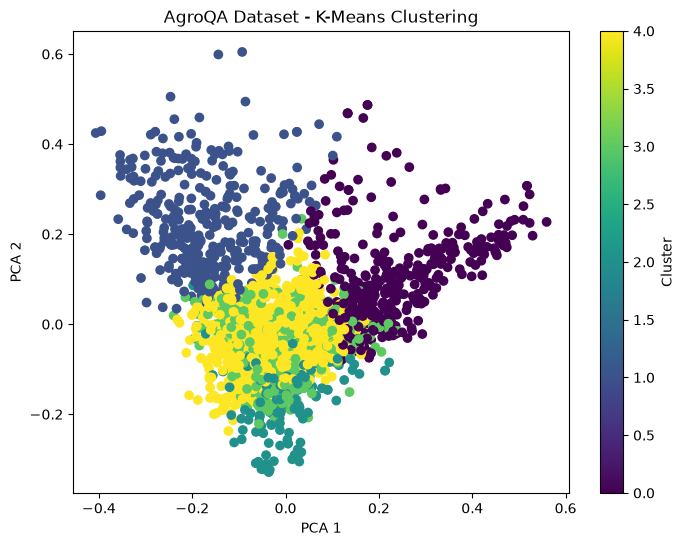


Done! Saved as AgroQA_KMeans_Result.csv


In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

nltk.download("stopwords")
nltk.download("wordnet")

# 1. Load dataset
df = pd.read_csv("AgroQA Dataset.csv")
print(df.head())
print(df.columns)

# 2. Select text columns
# Change these names if required
question_col = "Question"
answer_col = "Answer"

df["text"] = df[question_col].fillna("") + " " + df[answer_col].fillna("")

# 3. NLP preprocessing
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", str(text).lower())
    words = text.split()
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

# 4. TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 6. Show clusters
for i in range(k):
    print("\nCLUSTER", i)
    print(df[df["Cluster"] == i][question_col].head(10).to_string(index=False))

# 7. Important words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(k):
    words = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i} keywords:")
    print(", ".join(terms[words]))

# 8. Visualisation
pca = PCA(n_components=2, random_state=42)
X_2D = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("AgroQA Dataset - K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

# 9. Save result
df.to_csv("AgroQA_KMeans_Result.csv", index=False)

print("\nDone! Saved as AgroQA_KMeans_Result.csv")